## ASSIGNMENT NO:6

Name:SAWANT SEJAL RAKESH 
Batch - B
Roll No:2317114

Title-Building and Testing an AI Model
Develop and test an AI model for a simple yet practical application (e.g., movie recommendation
system, AI-based spam detector, sentiment analysis tool). Use appropriate datasets and evaluate
accuracy, precision, and recall.


In [9]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/admin1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
# Load Dataset
data = pd.read_csv("IMDb Movies India.csv")

print(data.head())
print(data.info())

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe1 in position 76763: invalid continuation byte

In [5]:
# Select useful columns
data = data[['overview','score','genre']]

In [7]:
# Create Sentiment Label
data['sentiment'] = data['score'].apply(lambda x: 1 if x >= 7 else 0)

print(data.head())

                                            overview  score  \
0  After dominating the boxing world, Adonis Cree...   73.0   
1  Set more than a decade after the events of the...   78.0   
2  While working underground to fix a water main,...   76.0   
3  Through a series of unfortunate events, three ...   70.0   
4  Good-hearted teenager William always lived in ...   61.0   

                                           genre  sentiment  
0                                  Drama, Action          1  
1             Science Fiction, Adventure, Action          1  
2  Animation, Adventure, Family, Fantasy, Comedy          1  
3  Animation, Comedy, Family, Adventure, Fantasy          1  
4                                         Action          1  


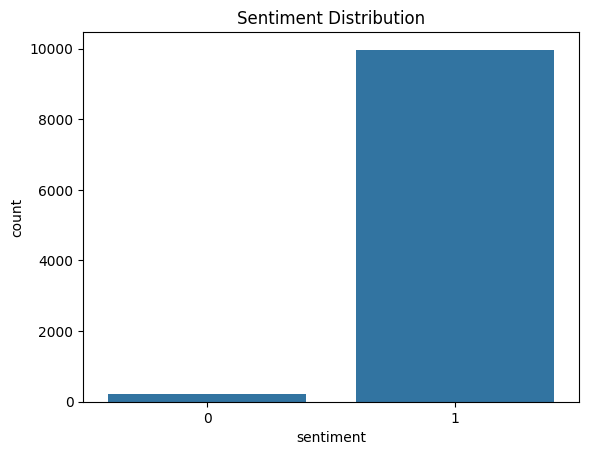

In [9]:
# Sentiment distribution
sns.countplot(x='sentiment', data=data)
plt.title("Sentiment Distribution")
plt.show()

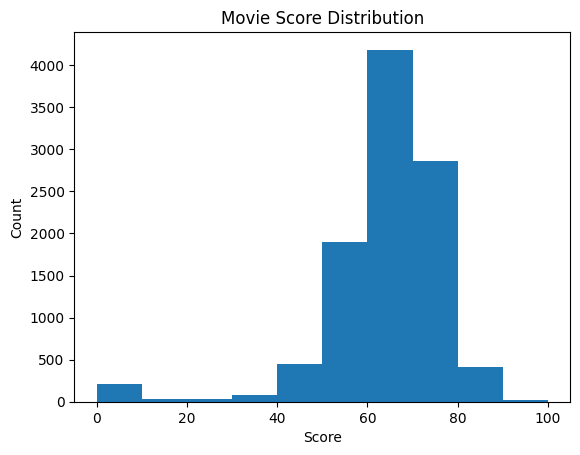

In [11]:
# Score distribution
plt.hist(data['score'], bins=10)
plt.title("Movie Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

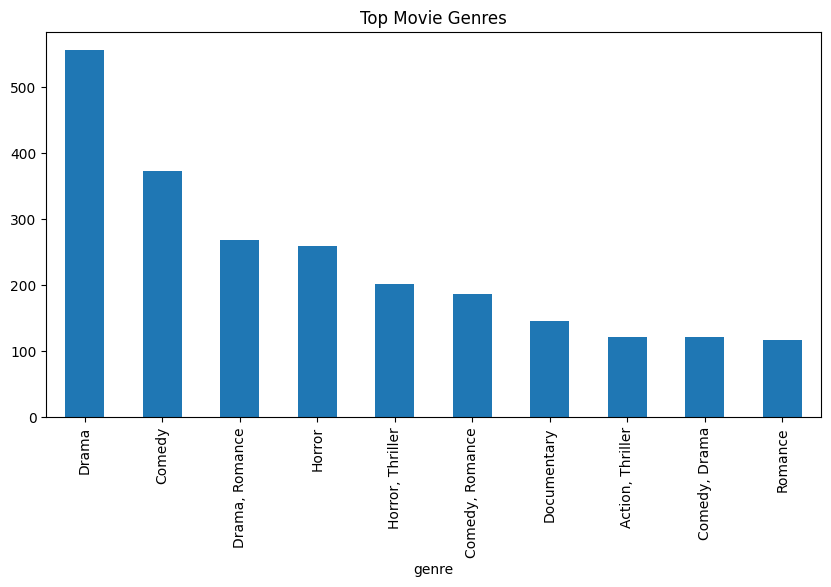

In [13]:
# Genre distribution
plt.figure(figsize=(10,5))
data['genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top Movie Genres")
plt.show()

In [15]:
# Text Preprocessing
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

corpus = []

for i in range(len(data)):

    review = re.sub('[^a-zA-Z]', ' ', str(data['overview'][i]))
    review = review.lower()
    review = review.split()

    review = [ps.stem(word) for word in review if word not in stop_words]
    review = " ".join(review)

    corpus.append(review)

In [16]:
# Feature Extraction
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(corpus).toarray()
y = data['sentiment']

In [17]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# Train AI Model
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [23]:
# Prediction
y_pred = model.predict(X_test)

In [25]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9828094302554028

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        35
           1       0.98      1.00      0.99      2001

    accuracy                           0.98      2036
   macro avg       0.49      0.50      0.50      2036
weighted avg       0.97      0.98      0.97      2036



/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/admin1/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


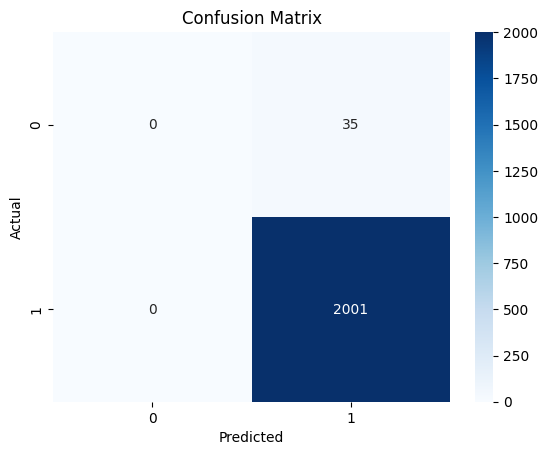

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
# Test with New Review
sample = ["This movie is fantastic with great acting and story"]

sample = re.sub('[^a-zA-Z]', ' ', sample[0]).lower().split()
sample = [ps.stem(word) for word in sample if word not in stop_words]
sample = " ".join(sample)

sample_vector = vectorizer.transform([sample]).toarray()

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Prediction: Positive Movie")
else:
    print("Prediction: Negative Movie")

Prediction: Positive Movie
